In [16]:
from z3 import *
import numpy as np
import random
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.autolayout"] = True # to for tight_layout()
import arviz as az
# our library
from z3 import *
import numpy as np
import re
import arviz as az
import matplotlib.pyplot as plt
import os, sys
from importlib import reload
import pickle as pkl
from datetime import datetime

project_root = os.path.abspath(os.path.join(os.getcwd(), "..",))
sys.path.append(project_root)

import src.sat_metropolis.sat as sat
import src.sat_metropolis.smt as smt
import src.sat_metropolis.mcmc as mcmc
import src.sat_metropolis.utils as utils
import src.sat_metropolis.models as models
# from sat_metropolis import smt, mcmc, sat, utils

reload(sat)
reload(smt)
reload(mcmc)
reload(utils)
reload(models)

with open("ResultsRoadsCmsgen.pkl", "rb") as f:
    data = pkl.load(f)


with open("extracted_results_with_indices.pkl", "rb") as f:
    spurdata = pkl.load(f)

In [17]:
spurdata

[{'connections': 2,
  'reduction': 1,
  'data': {100: [Inference data with groups:
    	> posterior, [0.06566988700069487]],
   500: [Inference data with groups:
    	> posterior, [0.0863532210350968]],
   1000: [Inference data with groups:
    	> posterior,
    [0.08856273896526545]],
   3000: [Inference data with groups:
    	> posterior,
    [0.10217733401805162]],
   7000: [Inference data with groups:
    	> posterior,
    [0.09565050998935476]]}},
 {'connections': 2,
  'reduction': 2,
  'data': {100: [Inference data with groups:
    	> posterior, [0.06638108100742102]],
   500: [Inference data with groups:
    	> posterior, [0.06510775996139273]],
   1000: [Inference data with groups:
    	> posterior,
    [0.06182214297587052]],
   3000: [Inference data with groups:
    	> posterior,
    [0.07151249796152115]],
   7000: [Inference data with groups:
    	> posterior,
    [0.06890674098394811]]}},
 {'connections': 2,
  'reduction': 4,
  'data': {100: [Inference data with groups:
  

In [18]:
from arviz_stats.metrics import kl_divergence

In [19]:
from arviz_stats import kl_divergence
import numpy as np


def discrete_tv_goal_to_proposed(goal_trace, proposed_trace, var_name="theta"):
    goal_vals = np.asarray(goal_trace.posterior[var_name].values).ravel()
    prop_vals = np.asarray(proposed_trace.posterior[var_name].values).ravel()

    bins = np.union1d(goal_vals, prop_vals)

    goal_counts = np.array([(goal_vals == b).sum() for b in bins], dtype=float)
    prop_counts = np.array([(prop_vals == b).sum() for b in bins], dtype=float)

    p = goal_counts / goal_counts.sum()
    q = prop_counts / prop_counts.sum()

    return float(0.5 * np.sum(np.abs(p - q)))

def avg_discrete_tv_goal_to_proposed(goal_trace, proposed_trace, var_names=None):
    if var_names is None:
        var_names = sorted(
            set(goal_trace.posterior.data_vars)
            & set(proposed_trace.posterior.data_vars)
        )

    if isinstance(var_names, str):
        var_names = [var_names]

    vals = [
        discrete_tv_goal_to_proposed(goal_trace, proposed_trace, var_name=v)
        for v in var_names
    ]

    return float(np.mean(vals))

def load_spur(spurdata, connections, rf, samples, idx=0):
    row = next(
        x for x in spurdata
        if x["connections"] == connections and x["reduction"] == rf
    )
    return row["data"][samples][idx]




def load_roads_cmsgen_longrun(connections, rf=1, run=0, D=4, samples=5000, idx=0):
    run=data[connections][rf][run][D][samples]
    return run

import numpy as np
import matplotlib.pyplot as plt

def plot_kl_vs_cumulative_time(data, connections, rf, run, Ds, samples, LOG=False):
    plt.figure(figsize=(8, 5))

    for D in Ds:
        entry = data[connections][rf][run][D][samples]

        times_between_samples = np.asarray(entry[1], dtype=float)
        kls = np.asarray(entry[2], dtype=float)

        cumulative_time = np.cumsum(times_between_samples)

        n = min(len(cumulative_time), len(kls))
        x = cumulative_time[:n]
        y = kls[:n]

        plt.plot(x, y, label=f"D={D}")

        # label at head/end of line
        if n > 0:
            plt.text(
                x[-1],
                y[-1],
                f" D={D}",
                va="center",
                fontsize=9,
            )

    if LOG:
        plt.xscale("log")

    plt.xlabel("Cumulative time")
    plt.ylabel("KL")
    plt.title(f"KL vs cumulative time | connections={connections}, rf={rf}, samples={samples}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
connections = 3
rf = 1
Ds=ds = [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100,1000000000]
samples = 1000


In [21]:
goal_trace = load_spur(spurdata, connections=connections, rf=rf, samples=samples)

for D in Ds:
    proposed_trace = data[connections][rf][0][D][samples][0]
    kls = []

    n_draws = proposed_trace.posterior.sizes["draw"]
    last_kl = None

    for sample_count in range(1, n_draws + 1):
        should_compute = (
            sample_count <= 100
            or (sample_count <= 500 and sample_count % 10 == 0)
            or (sample_count > 500 and sample_count % 40 == 0)
            or sample_count == n_draws
        )

        if should_compute:
            print(f"Processing D={D}, sample_count={sample_count}/{n_draws}")

            partial_trace = proposed_trace.isel(draw=slice(0, sample_count))

            dist = avg_discrete_tv_goal_to_proposed(goal_trace, partial_trace)

        kls.append(dist)

    entry = data[connections][rf][0][D][samples]

    if len(entry) >= 3:
        entry[2] = kls
    else:
        entry.append(kls)

Processing D=1, sample_count=1/1000
Processing D=1, sample_count=2/1000
Processing D=1, sample_count=3/1000
Processing D=1, sample_count=4/1000
Processing D=1, sample_count=5/1000
Processing D=1, sample_count=6/1000
Processing D=1, sample_count=7/1000
Processing D=1, sample_count=8/1000
Processing D=1, sample_count=9/1000
Processing D=1, sample_count=10/1000
Processing D=1, sample_count=11/1000
Processing D=1, sample_count=12/1000
Processing D=1, sample_count=13/1000
Processing D=1, sample_count=14/1000
Processing D=1, sample_count=15/1000
Processing D=1, sample_count=16/1000
Processing D=1, sample_count=17/1000
Processing D=1, sample_count=18/1000
Processing D=1, sample_count=19/1000
Processing D=1, sample_count=20/1000
Processing D=1, sample_count=21/1000
Processing D=1, sample_count=22/1000
Processing D=1, sample_count=23/1000
Processing D=1, sample_count=24/1000
Processing D=1, sample_count=25/1000
Processing D=1, sample_count=26/1000
Processing D=1, sample_count=27/1000
Processing

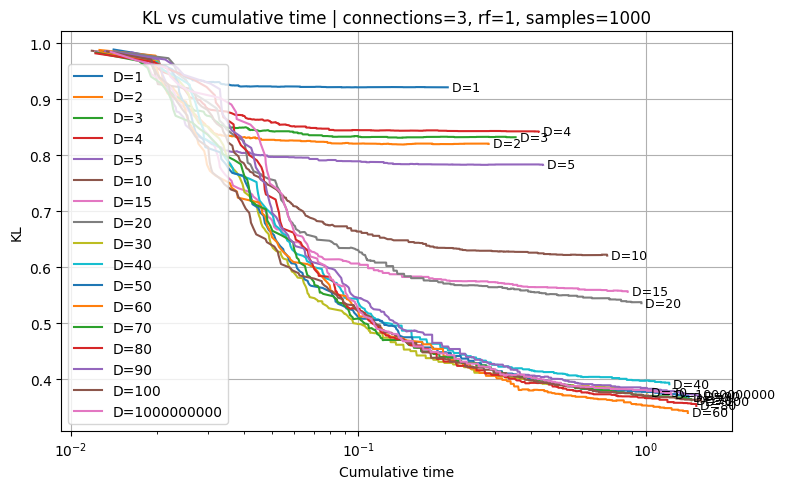

In [22]:
plot_kl_vs_cumulative_time(
    data=data,
    connections=connections,
    rf=rf,
    run=0,
    Ds=Ds,
    samples=samples,
    LOG=True,
)

In [23]:
10**-2

0.01